# 01_eda — Role A: Exploratory Data Analysis

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src.data import RAW_DATA_PATH

FIG_DIR = Path.cwd().parent / "figures"
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
df = pd.read_csv(RAW_DATA_PATH)
df.shape

(4424, 37)

## Xác nhận số liệu thực tế (không copy từ metadata UCI)

Đối chiếu cảnh báo ở `docs/02-DATASET-VA-CONG-VIEC.md` Phần A2: trang UCI ghi 36 feature,
nhưng bài báo gốc (Table 1) chỉ liệt kê 34. Chênh lệch nằm ở 2 cột `Previous qualification (grade)`
và `Admission grade` — có trong file CSV phát hành nhưng không có trong bảng bài báo.

In [2]:
print("df.shape:", df.shape)
print(f"-> {df.shape[1] - 1} feature + 1 cot Target (UCI ghi 36; bai bao goc chi liet ke 34, "
      "chenh lech la 'Previous qualification (grade)' va 'Admission grade')")
df.info()

df.shape: (4424, 37)
-> 36 feature + 1 cot Target (UCI ghi 36; bai bao goc chi liet ke 34, chenh lech la 'Previous qualification (grade)' va 'Admission grade')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                        

In [3]:
null_counts = df.isnull().sum()
print("Tong so gia tri thieu:", null_counts.sum())
null_counts[null_counts > 0]

Tong so gia tri thieu: 0


Series([], dtype: int64)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


## Hình 1 — Phân bố lớp target

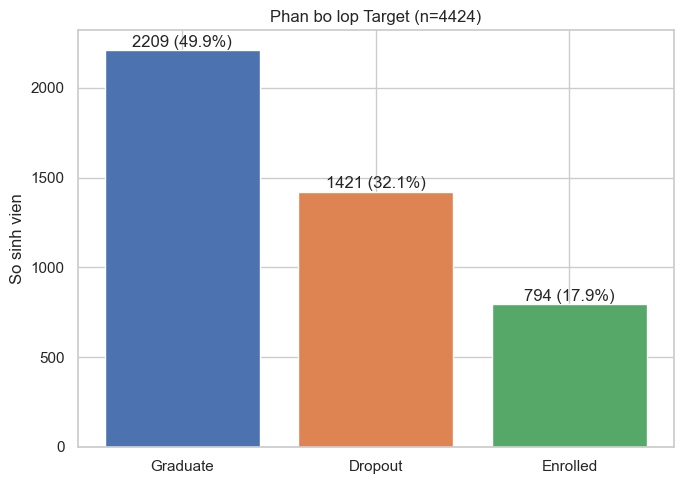

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [5]:
target_counts = df["Target"].value_counts()
target_pct = df["Target"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(target_counts.index, target_counts.values, color=["#4C72B0", "#DD8452", "#55A868"])
for bar, pct in zip(bars, target_pct[target_counts.index]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{bar.get_height():.0f} ({pct:.1f}%)", ha="center")
ax.set_title("Phan bo lop Target (n=4424)")
ax.set_ylabel("So sinh vien")
fig.tight_layout()
fig.savefig(FIG_DIR / "A_target_distribution.png", dpi=150)
plt.show()

target_counts

## Hình 2 — Heatmap tương quan giữa các feature numeric

Dùng để đối chiếu bảng đa cộng tuyến ở `docs/02` Phần A6 (VD `1st sem (approved)` vs
`2nd sem (approved)` r=0.904, `Nacionality` vs `International` r=0.912).

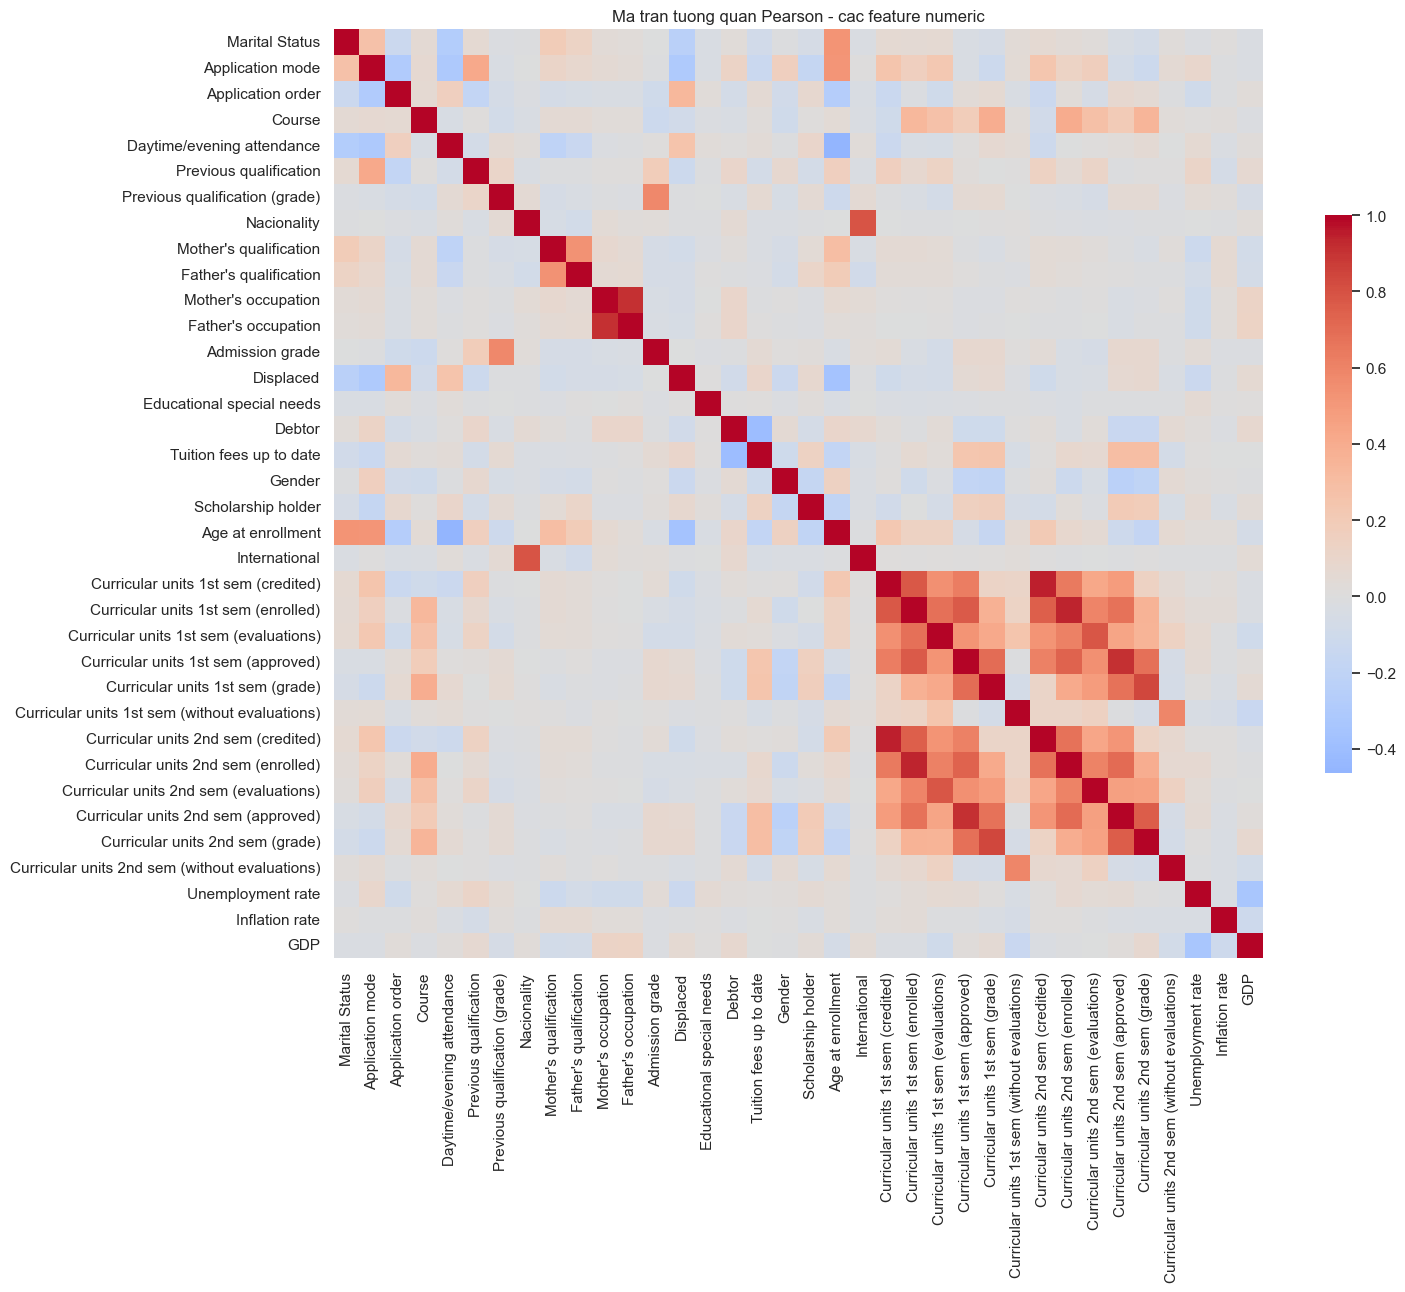

In [6]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            xticklabels=True, yticklabels=True, ax=ax,
            cbar_kws={"shrink": 0.6})
ax.set_title("Ma tran tuong quan Pearson - cac feature numeric")
fig.tight_layout()
fig.savefig(FIG_DIR / "A_correlation_heatmap.png", dpi=150)
plt.show()

In [7]:
pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            pairs.append((cols[i], cols[j], round(r, 3)))
pd.DataFrame(pairs, columns=["feature_1", "feature_2", "pearson_r"]).sort_values(
    "pearson_r", key=abs, ascending=False
)

,feature_1,feature_2,pearson_r
3,Curricular units 1st sem (credited),Curricular units 2nd sem (credited),0.945
6,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.943
1,Mother's occupation,Father's occupation,0.910
9,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.904
10,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),0.837
0,Nacionality,International,0.791
7,Curricular units 1st sem (evaluations),Curricular units 2nd sem (evaluations),0.779
2,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),0.774
4,Curricular units 1st sem (enrolled),Curricular units 1st sem (approved),0.769
12,Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),0.761


## Hình 3 — Curricular units 2nd sem (approved) theo Target

Đây là feature quan trọng nhất theo permutation importance của bài báo gốc (Phần A5).

C:\Users\Phuc\AppData\Local\Temp\ipykernel_9464\4022750629.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (approved)",


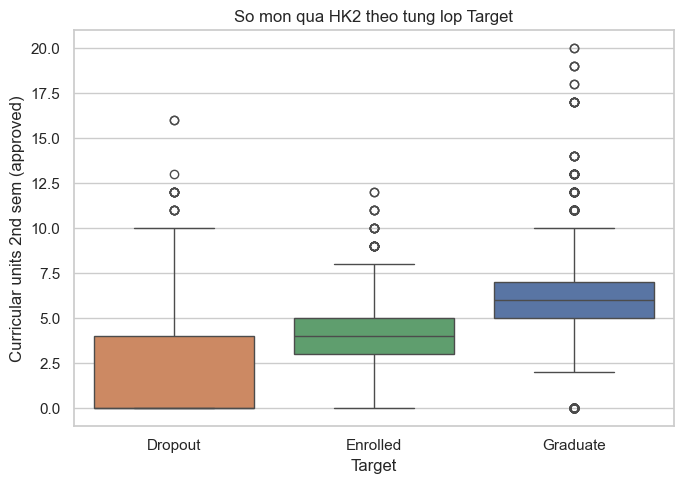

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (approved)",
            order=["Dropout", "Enrolled", "Graduate"], ax=ax,
            palette=["#DD8452", "#55A868", "#4C72B0"])
ax.set_title("So mon qua HK2 theo tung lop Target")
fig.tight_layout()
fig.savefig(FIG_DIR / "A_curricular_units_2nd_sem_by_target.png", dpi=150)
plt.show()

## Hình 4 — Tuition fees up to date & Scholarship holder vs Target

Đối chiếu quan sát ở `docs/02` Phần A7: sinh viên đóng học phí đúng hạn / có học bổng
thành công hơn rõ rệt.

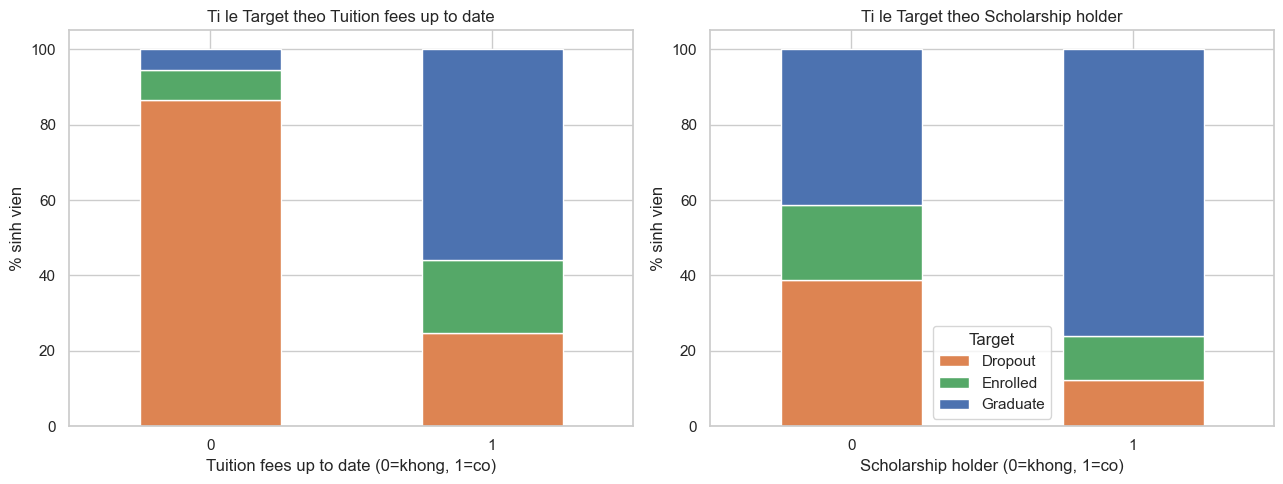

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in zip(
    axes,
    ["Tuition fees up to date", "Scholarship holder"],
    ["Tuition fees up to date", "Scholarship holder"],
):
    ct = pd.crosstab(df[col], df["Target"], normalize="index") * 100
    ct = ct[["Dropout", "Enrolled", "Graduate"]]
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=["#DD8452", "#55A868", "#4C72B0"], legend=(ax is axes[-1]))
    ax.set_title(f"Ti le Target theo {label}")
    ax.set_xlabel(label + " (0=khong, 1=co)")
    ax.set_ylabel("% sinh vien")
    ax.tick_params(axis="x", rotation=0)

fig.tight_layout()
fig.savefig(FIG_DIR / "A_tuition_scholarship_vs_target.png", dpi=150)
plt.show()

## Hình 5 — Tỉ lệ tốt nghiệp/bỏ học theo ngành (Course)

Đối chiếu Phần A7: Điều dưỡng/Công tác xã hội tốt nghiệp cao nhất; Công nghệ nhiên liệu
sinh học/Kỹ thuật CNTT thấp nhất. `Course` chỉ là mã số trong dataset (không có tên ngành
kèm theo), nên biểu đồ dùng mã số — đối chiếu với bảng ánh xạ trong bài báo gốc khi viết báo cáo.

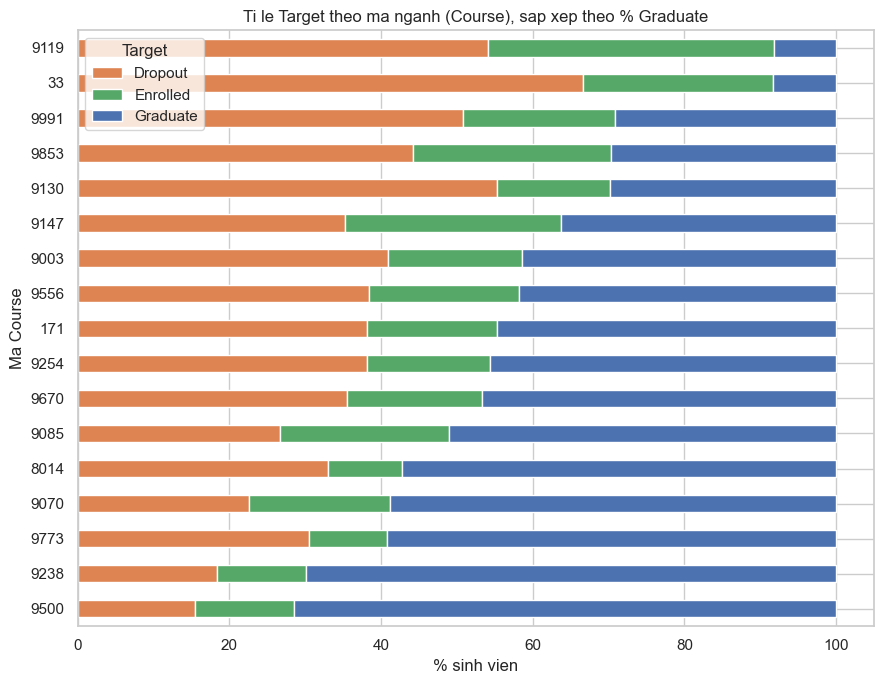

In [10]:
course_target = pd.crosstab(df["Course"], df["Target"], normalize="index") * 100
course_target = course_target[["Dropout", "Enrolled", "Graduate"]].sort_values(
    "Graduate", ascending=False
)

fig, ax = plt.subplots(figsize=(9, 7))
course_target.plot(kind="barh", stacked=True, ax=ax,
                    color=["#DD8452", "#55A868", "#4C72B0"])
ax.set_title("Ti le Target theo ma nganh (Course), sap xep theo % Graduate")
ax.set_xlabel("% sinh vien")
ax.set_ylabel("Ma Course")
fig.tight_layout()
fig.savefig(FIG_DIR / "A_target_by_course.png", dpi=150)
plt.show()

## Kiểm tra pipeline `src/data.py`

Xác nhận `get_train_test()` chạy được, trả về đúng 4 giá trị đã stratify.

In [11]:
from src.data import get_train_test

X_train, X_test, y_train, y_test = get_train_test()
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("So feature sau one-hot:", X_train.shape[1])
print("\nTi le lop trong train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTi le lop trong test:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (3539, 90) | X_test: (885, 90)
So feature sau one-hot: 90

Ti le lop trong train:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Ti le lop trong test:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64
